## LEARNING CURVE — MASTER CODE

### Imports & Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

sns.set(style="whitegrid")
np.random.seed(42)


In [2]:
# Dataset
data = load_breast_cancer()
X = data.data
y = data.target


### Basic Learning Curve (Accuracy)

In [3]:
model = LogisticRegression(max_iter=3000)

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)


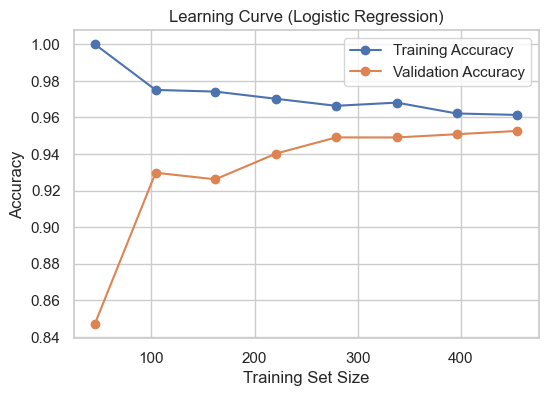

In [4]:
plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_mean, "o-", label="Training Accuracy")
plt.plot(train_sizes, val_mean, "o-", label="Validation Accuracy")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (Logistic Regression)")
plt.legend()
plt.show()


### Learning Curve with Variance (Error Bands)

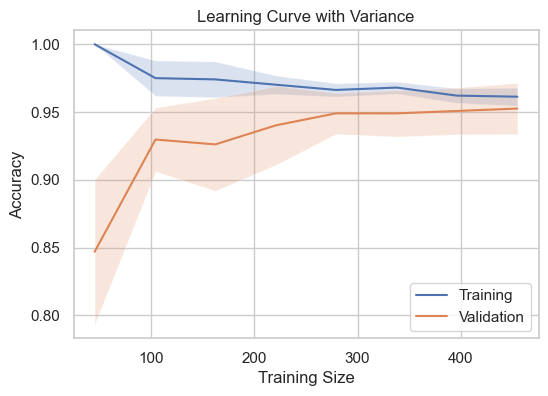

In [5]:
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(6, 4))
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)
plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.plot(train_sizes, train_mean, label="Training")
plt.plot(train_sizes, val_mean, label="Validation")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve with Variance")
plt.legend()
plt.show()


### Overfitting Example (High Variance Model)

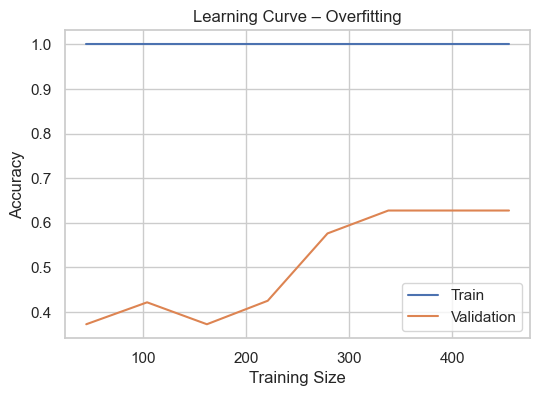

In [6]:
overfit_model = SVC(kernel="rbf", gamma=5)

train_sizes, train_scores, val_scores = learning_curve(
    overfit_model,
    X,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation")
plt.title("Learning Curve – Overfitting")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


### Underfitting Example (High Bias Model)

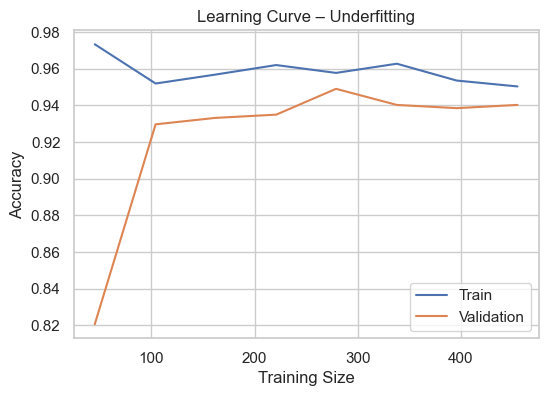

In [7]:
underfit_model = LogisticRegression(C=0.01, max_iter=3000)

train_sizes, train_scores, val_scores = learning_curve(
    underfit_model,
    X,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation")
plt.title("Learning Curve – Underfitting")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


### Compare Learning Curves Across Models

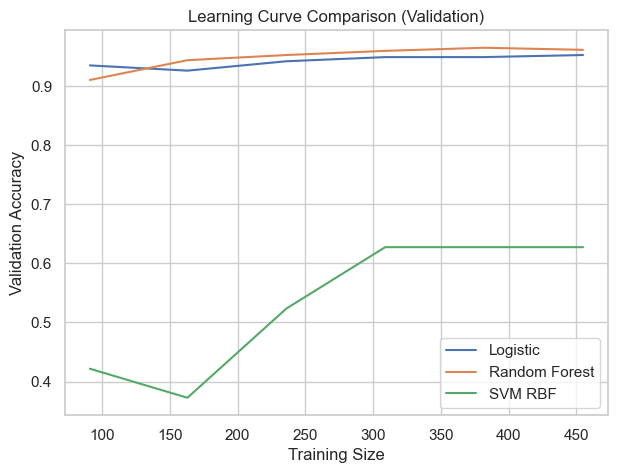

In [8]:
models = {
    "Logistic": LogisticRegression(max_iter=3000),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "SVM RBF": SVC(kernel="rbf", gamma=1)
}

plt.figure(figsize=(7, 5))

for name, model in models.items():
    sizes, train_s, val_s = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy",
        train_sizes=np.linspace(0.2, 1.0, 6),
        n_jobs=-1
    )
    plt.plot(sizes, val_s.mean(axis=1), label=name)

plt.xlabel("Training Size")
plt.ylabel("Validation Accuracy")
plt.title("Learning Curve Comparison (Validation)")
plt.legend()
plt.show()


### Learning Curve with Loss (Negative Log Loss)

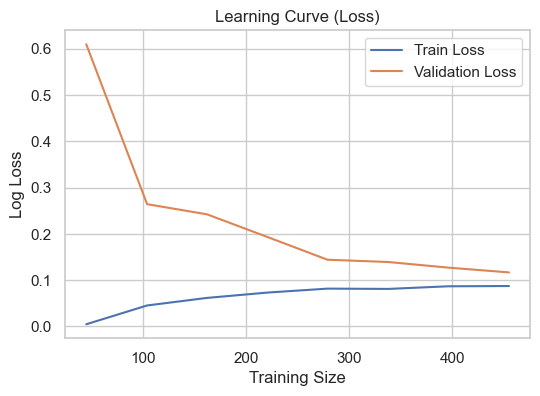

In [9]:
model = LogisticRegression(max_iter=3000)

sizes, train_loss, val_loss = learning_curve(
    model,
    X,
    y,
    cv=5,
    scoring="neg_log_loss",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

plt.figure(figsize=(6, 4))
plt.plot(sizes, -train_loss.mean(axis=1), label="Train Loss")
plt.plot(sizes, -val_loss.mean(axis=1), label="Validation Loss")
plt.xlabel("Training Size")
plt.ylabel("Log Loss")
plt.title("Learning Curve (Loss)")
plt.legend()
plt.show()
